# 06 ReturnShield Agent Demo

## Scope

Run the Risk Agent demo on the cart-level input table from Notebook 05.

Input:

```text
data/processed/mock_cart_features.csv
```

Notebook-specific agent outputs and plots:

```text
outputs/06_returnshield_agent_demo/
```


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 240)


def find_repo_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for path in [current, *current.parents]:
        if (path / "notebooks").exists() and (path / "data").exists():
            return path
    if current.name == "notebooks":
        return current.parent
    return current


REPO_ROOT = find_repo_root()
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
OUTPUTS_DIR = REPO_ROOT / "outputs"
NOTEBOOK_OUTPUT_DIR = OUTPUTS_DIR / "06_returnshield_agent_demo"
PLOTS_DIR = NOTEBOOK_OUTPUT_DIR / "plots"

NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = PROCESSED_DIR / "mock_cart_features.csv"

OUTPUT_PATHS = {
    "cart_scores": NOTEBOOK_OUTPUT_DIR / "returnshield_agent_cart_scores.csv",
    "config": NOTEBOOK_OUTPUT_DIR / "returnshield_agent_config.csv",
    "summary": NOTEBOOK_OUTPUT_DIR / "returnshield_agent_summary.csv",
    "diagnostics": NOTEBOOK_OUTPUT_DIR / "returnshield_agent_diagnostics.csv",
}

print("Repo root:", REPO_ROOT)
print("Input:", INPUT_PATH)
print("Notebook output dir:", NOTEBOOK_OUTPUT_DIR)
print("Plots dir:", PLOTS_DIR)
for name, path in OUTPUT_PATHS.items():
    print(f"{name}: {path}")


Repo root: C:\Users\monster\Desktop\returnshield-ai
Input: C:\Users\monster\Desktop\returnshield-ai\data\processed\mock_cart_features.csv
Notebook output dir: C:\Users\monster\Desktop\returnshield-ai\outputs\06_returnshield_agent_demo
Plots dir: C:\Users\monster\Desktop\returnshield-ai\outputs\06_returnshield_agent_demo\plots
cart_scores: C:\Users\monster\Desktop\returnshield-ai\outputs\06_returnshield_agent_demo\returnshield_agent_cart_scores.csv
config: C:\Users\monster\Desktop\returnshield-ai\outputs\06_returnshield_agent_demo\returnshield_agent_config.csv
summary: C:\Users\monster\Desktop\returnshield-ai\outputs\06_returnshield_agent_demo\returnshield_agent_summary.csv
diagnostics: C:\Users\monster\Desktop\returnshield-ai\outputs\06_returnshield_agent_demo\returnshield_agent_diagnostics.csv


## 1. Load agent input

The input table must not already contain final agent outputs.


In [2]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(f"Missing input file: {INPUT_PATH}")

cart_features = pd.read_csv(INPUT_PATH)

print("Loaded cart features:", cart_features.shape)
cart_features.head()


Loaded cart features: (50, 30)


,cart_id,mock_user_id,primary_mock_product_id,primary_source_item_id,cart_item_count,unique_mock_product_count,two_size_same_product,duplicate_variant,cart_uncertainty_signal_count,cart_size_pressure,model_risk_rank_score,model_risk_score_raw,night_purchase,fit_layer_summary_score,item_fit_issue_score,item_length_issue_score,item_quality_issue_score,review_text_summary_score,review_text_size_issue_score,review_text_quality_issue_score,review_text_color_issue_score,review_text_negative_language_score,rating_issue_score,review_text_color_issue_score_upper_tail_flag,fit_signal_available,review_signal_available,rating_signal_available,review_text_size_issue_score_upper_tail_flag,review_text_quality_issue_score_upper_tail_flag,review_text_negative_language_score_upper_tail_flag
0,CART_0001,MU_003,MP_0095,modcloth_637931,4,4,0,0,0,0.6,0.980862,0.735791,0.0,0.329965,0.351079,0.348145,0.281416,0.202710,0.327054,0.073045,0.004463,0.144339,0.135354,0,1,1,1,0,0,0
1,CART_0002,MU_003,MP_0056,renttherunway_466944,5,3,1,0,1,0.8,0.850513,0.425136,0.0,0.313525,0.313525,NaN,NaN,0.190963,0.294869,0.055416,0.003336,0.144698,0.142092,0,1,1,1,0,0,0
2,CART_0003,MU_023,MP_0135,renttherunway_1188641,5,4,0,1,1,0.8,0.977976,0.721843,0.0,0.292656,0.296385,0.263702,0.262527,0.214422,0.325496,0.053909,0.004812,0.138017,0.110102,0,1,1,1,0,0,0
3,CART_0004,MU_026,MP_0045,renttherunway_2531779,2,2,0,0,0,0.2,0.855777,0.433196,0.0,0.308812,0.308812,NaN,NaN,0.188738,0.314503,0.048828,0.004358,0.133705,0.105078,0,1,1,1,0,0,0
4,CART_0005,MU_024,MP_0123,renttherunway_535046,3,3,0,0,0,0.4,0.850513,0.425136,0.0,0.313525,0.313525,NaN,NaN,0.206175,0.350879,0.062141,0.004812,0.144698,0.142092,0,1,1,1,0,0,0


## 2. Input checks

Notebook 05 should provide input features only. Notebook 06 is the first step that creates `risk_score`, `risk_level`, actions, and dashboard messages.


In [3]:
forbidden_input_cols = {
    "risk_score",
    "risk_level",
    "top_reasons",
    "suggested_action",
    "dashboard_message",
    "demo_reference_risk_score",
    "demo_reference_risk_level",
    "cart_uncertainty_score",
}

leaked_cols = forbidden_input_cols.intersection(cart_features.columns)
if leaked_cols:
    raise ValueError(f"Notebook 05 output already contains agent output columns: {sorted(leaked_cols)}")

required_cols = {
    "cart_id",
    "mock_user_id",
    "model_risk_rank_score",
    "fit_layer_summary_score",
    "review_text_summary_score",
    "two_size_same_product",
    "duplicate_variant",
    "cart_uncertainty_signal_count",
    "cart_size_pressure",
    "fit_signal_available",
    "review_signal_available",
    "rating_signal_available",
}

missing_required = required_cols - set(cart_features.columns)
if missing_required:
    raise KeyError(f"Missing required input columns: {sorted(missing_required)}")

assert cart_features["cart_id"].is_unique, "Input must have one row per cart."
assert cart_features["model_risk_rank_score"].notna().any(), "model_risk_rank_score has zero coverage."

all_empty_cols = [
    col for col in cart_features.columns
    if cart_features[col].isna().all()
]

assert not all_empty_cols, f"Input contains all-empty columns: {all_empty_cols}"

print("Input checks passed.")


Input checks passed.


## 3. Risk Agent policy config

The final score uses two parts:

1. **Transaction anchor:** label-backed return/cancel ranking from Notebook 02.
2. **Contextual evidence:** fit, review, and cart signals that make the risk actionable.

This avoids two problems at the same time:

- the score is not reduced to only the transaction model;
- weak auxiliary signals are not artificially stretched into calibrated probabilities.

Fit and review signals affect the score through upper-tail evidence flags and drive the explanation/action layer.


In [4]:
RISK_POLICY = {
    "transaction_anchor_weight": 0.70,
    "contextual_evidence_weight": 0.30,
    "reason_quantile": 0.75,
}

CONTEXT_POLICY = {
    "fit_context_weight": 0.45,
    "review_context_weight": 0.40,
    "cart_context_weight": 0.15,
}

assert np.isclose(
    RISK_POLICY["transaction_anchor_weight"] + RISK_POLICY["contextual_evidence_weight"],
    1.0,
), "Risk policy weights must sum to 1."

assert np.isclose(sum(CONTEXT_POLICY.values()), 1.0), "Context policy weights must sum to 1."

policy_rows = [
    {
        "policy_group": "risk_score",
        "name": "transaction_anchor_weight",
        "value": RISK_POLICY["transaction_anchor_weight"],
        "reason": "label-backed return/cancel ranking remains the risk anchor",
    },
    {
        "policy_group": "risk_score",
        "name": "contextual_evidence_weight",
        "value": RISK_POLICY["contextual_evidence_weight"],
        "reason": "fit, review, and cart evidence can adjust the risk score but do not replace the label-backed anchor",
    },
    {
        "policy_group": "reason_threshold",
        "name": "reason_quantile",
        "value": RISK_POLICY["reason_quantile"],
        "reason": "upper-tail signals are used for explanations and contextual evidence",
    },
]

for name, value in CONTEXT_POLICY.items():
    policy_rows.append(
        {
            "policy_group": "contextual_evidence",
            "name": name,
            "value": value,
            "reason": "context signal weight used inside contextual evidence score",
        }
    )

agent_config = pd.DataFrame(policy_rows)
agent_config.to_csv(OUTPUT_PATHS["config"], index=False)

print("Saved:", OUTPUT_PATHS["config"])
agent_config


Saved: C:\Users\monster\Desktop\returnshield-ai\outputs\06_returnshield_agent_demo\returnshield_agent_config.csv


,policy_group,name,value,reason
0,risk_score,transaction_anchor_weight,0.70,label-backed return/cancel ranking remains the...
1,risk_score,contextual_evidence_weight,0.30,"fit, review, and cart evidence can adjust the ..."
2,reason_threshold,reason_quantile,0.75,upper-tail signals are used for explanations a...
3,contextual_evidence,fit_context_weight,0.45,context signal weight used inside contextual e...
4,contextual_evidence,review_context_weight,0.40,context signal weight used inside contextual e...
5,contextual_evidence,cart_context_weight,0.15,context signal weight used inside contextual e...


## 4. Layer scores

Create the layer scores used by the Risk Agent.

Missing optional layers stay missing and are handled by available-weight averaging.


In [5]:
agent_input = cart_features.copy()

numeric_cols = [
    "model_risk_rank_score",
    "fit_layer_summary_score",
    "review_text_summary_score",
    "cart_uncertainty_signal_count",
    "cart_size_pressure",
    "fit_signal_available",
    "review_signal_available",
    "rating_signal_available",
]

optional_numeric_cols = [
    "item_fit_issue_score",
    "item_length_issue_score",
    "item_quality_issue_score",
    "review_text_size_issue_score",
    "review_text_quality_issue_score",
    "review_text_color_issue_score",
    "review_text_negative_language_score",
    "rating_issue_score",
    "review_text_color_issue_score_upper_tail_flag",
    "review_text_size_issue_score_upper_tail_flag",
    "review_text_quality_issue_score_upper_tail_flag",
    "review_text_negative_language_score_upper_tail_flag",
]

for col in numeric_cols + optional_numeric_cols:
    if col in agent_input.columns:
        agent_input[col] = pd.to_numeric(agent_input[col], errors="coerce")

agent_input["transaction_layer_score"] = agent_input["model_risk_rank_score"].clip(0, 1)

agent_input["fit_layer_agent_score"] = np.where(
    agent_input["fit_signal_available"].eq(1),
    agent_input["fit_layer_summary_score"].clip(0, 1),
    np.nan,
)

agent_input["review_layer_agent_score"] = np.where(
    agent_input["review_signal_available"].eq(1),
    agent_input["review_text_summary_score"].clip(0, 1),
    np.nan,
)

agent_input["cart_behavior_agent_score"] = (
    0.70 * (agent_input["cart_uncertainty_signal_count"].clip(0, 2) / 2)
    + 0.30 * agent_input["cart_size_pressure"].clip(0, 1)
).clip(0, 1)

agent_input[
    [
        "cart_id",
        "transaction_layer_score",
        "fit_layer_agent_score",
        "review_layer_agent_score",
        "cart_behavior_agent_score",
    ]
].head()


,cart_id,transaction_layer_score,fit_layer_agent_score,review_layer_agent_score,cart_behavior_agent_score
0,CART_0001,0.980862,0.329965,0.202710,0.18
1,CART_0002,0.850513,0.313525,0.190963,0.59
2,CART_0003,0.977976,0.292656,0.214422,0.59
3,CART_0004,0.855777,0.308812,0.188738,0.06
4,CART_0005,0.850513,0.313525,0.206175,0.12


## 5. Contextual evidence

Fit, review, and cart behavior are used as contextual evidence.

The auxiliary scores are not stretched or treated as calibrated probabilities. Instead, each layer contributes when it is high relative to the current demo batch or when an explicit flag is present.


In [6]:
def threshold_for(col, q=None):
    q = RISK_POLICY["reason_quantile"] if q is None else q

    if col not in agent_input.columns:
        return np.inf

    values = pd.to_numeric(agent_input[col], errors="coerce").dropna()
    if values.empty:
        return np.inf

    return float(values.quantile(q))


reason_thresholds = {
    "model_risk_rank_score": threshold_for("model_risk_rank_score"),
    "fit_layer_summary_score": threshold_for("fit_layer_summary_score"),
    "item_fit_issue_score": threshold_for("item_fit_issue_score"),
    "item_length_issue_score": threshold_for("item_length_issue_score"),
    "item_quality_issue_score": threshold_for("item_quality_issue_score"),
    "review_text_summary_score": threshold_for("review_text_summary_score"),
    "review_text_size_issue_score": threshold_for("review_text_size_issue_score"),
    "review_text_quality_issue_score": threshold_for("review_text_quality_issue_score"),
    "review_text_negative_language_score": threshold_for("review_text_negative_language_score"),
    "rating_issue_score": threshold_for("rating_issue_score"),
    "cart_size_pressure": threshold_for("cart_size_pressure"),
}

reason_thresholds_df = pd.DataFrame(
    [{"signal": k, "threshold": v} for k, v in reason_thresholds.items()]
)

reason_thresholds_df


,signal,threshold
0,model_risk_rank_score,0.919342
1,fit_layer_summary_score,0.352044
2,item_fit_issue_score,0.352209
3,item_length_issue_score,0.263702
4,item_quality_issue_score,0.269738
5,review_text_summary_score,0.228712
6,review_text_size_issue_score,0.357439
7,review_text_quality_issue_score,0.075617
8,review_text_negative_language_score,0.153097
9,rating_issue_score,0.136750


In [7]:
def is_high(row, col):
    if col not in row.index:
        return 0

    value = row.get(col, np.nan)
    threshold = reason_thresholds.get(col, np.inf)

    if pd.isna(value):
        return 0

    return int(value >= threshold)


def compute_fit_context_evidence(row):
    evidence_flags = [
        is_high(row, "fit_layer_summary_score"),
        is_high(row, "item_fit_issue_score"),
        is_high(row, "item_length_issue_score"),
        is_high(row, "item_quality_issue_score"),
    ]

    return max(evidence_flags)


def compute_review_context_evidence(row):
    evidence_flags = [
        is_high(row, "review_text_summary_score"),
        is_high(row, "review_text_size_issue_score"),
        is_high(row, "review_text_quality_issue_score"),
        is_high(row, "review_text_negative_language_score"),
        is_high(row, "rating_issue_score") if row.get("rating_signal_available", 0) == 1 else 0,
        int(row.get("review_text_color_issue_score_upper_tail_flag", 0) == 1),
    ]

    return max(evidence_flags)


def compute_cart_context_evidence(row):
    evidence_flags = [
        int(row.get("two_size_same_product", 0) == 1),
        int(row.get("duplicate_variant", 0) == 1),
        is_high(row, "cart_size_pressure"),
    ]

    return max(evidence_flags)


def weighted_average_available(values, weights):
    values = pd.Series(values, dtype="float")
    weights = pd.Series(weights, dtype="float")
    available = values.notna() & weights.notna() & (weights > 0)

    if not available.any():
        return np.nan

    return float((values[available] * weights[available]).sum() / weights[available].sum())


agent_input["fit_context_evidence_score"] = agent_input.apply(compute_fit_context_evidence, axis=1)
agent_input["review_context_evidence_score"] = agent_input.apply(compute_review_context_evidence, axis=1)
agent_input["cart_context_evidence_score"] = agent_input.apply(compute_cart_context_evidence, axis=1)

agent_input["contextual_evidence_score"] = agent_input.apply(
    lambda row: weighted_average_available(
        [
            row["fit_context_evidence_score"],
            row["review_context_evidence_score"],
            row["cart_context_evidence_score"],
        ],
        [
            CONTEXT_POLICY["fit_context_weight"],
            CONTEXT_POLICY["review_context_weight"],
            CONTEXT_POLICY["cart_context_weight"],
        ],
    ),
    axis=1,
)

agent_input["context_signal_count"] = (
    agent_input["fit_context_evidence_score"]
    + agent_input["review_context_evidence_score"]
    + agent_input["cart_context_evidence_score"]
)

agent_input[
    [
        "cart_id",
        "fit_context_evidence_score",
        "review_context_evidence_score",
        "cart_context_evidence_score",
        "contextual_evidence_score",
        "context_signal_count",
    ]
].head()


,cart_id,fit_context_evidence_score,review_context_evidence_score,cart_context_evidence_score,contextual_evidence_score,context_signal_count
0,CART_0001,1,0,1,0.60,2
1,CART_0002,0,1,1,0.55,2
2,CART_0003,1,0,1,0.60,2
3,CART_0004,0,0,0,0.00,0
4,CART_0005,0,1,0,0.40,1


## 6. Risk score

The final score is anchored by the transaction model and adjusted by contextual evidence.

This keeps the label-backed model visible while giving fit/review/cart signals real influence when they provide strong actionable evidence.


In [8]:
def compute_risk_score(row):
    return weighted_average_available(
        [
            row["transaction_layer_score"],
            row["contextual_evidence_score"],
        ],
        [
            RISK_POLICY["transaction_anchor_weight"],
            RISK_POLICY["contextual_evidence_weight"],
        ],
    )


def compute_available_weight(row):
    available_weight = 0.0

    if pd.notna(row.get("transaction_layer_score", np.nan)):
        available_weight += RISK_POLICY["transaction_anchor_weight"]

    if pd.notna(row.get("contextual_evidence_score", np.nan)):
        available_weight += RISK_POLICY["contextual_evidence_weight"]

    return available_weight


agent_input["label_backed_risk_score"] = agent_input["transaction_layer_score"]
agent_input["risk_score"] = agent_input.apply(compute_risk_score, axis=1).clip(0, 1)
agent_input["risk_input_coverage_weight"] = agent_input.apply(compute_available_weight, axis=1)

assert agent_input["risk_score"].between(0, 1).all(), "risk_score must be in [0, 1]."

agent_input[
    [
        "cart_id",
        "label_backed_risk_score",
        "contextual_evidence_score",
        "risk_score",
        "risk_input_coverage_weight",
    ]
].head()


,cart_id,label_backed_risk_score,contextual_evidence_score,risk_score,risk_input_coverage_weight
0,CART_0001,0.980862,0.60,0.866603,1.0
1,CART_0002,0.850513,0.55,0.760359,1.0
2,CART_0003,0.977976,0.60,0.864583,1.0
3,CART_0004,0.855777,0.00,0.599044,1.0
4,CART_0005,0.850513,0.40,0.715359,1.0


## 7. Risk levels

Risk levels are relative to the demo cart batch.

They are not production thresholds.


In [9]:
agent_input["risk_percentile_rank"] = agent_input["risk_score"].rank(pct=True, method="average")

agent_input["risk_level"] = np.select(
    [
        agent_input["risk_percentile_rank"] >= 0.75,
        agent_input["risk_percentile_rank"] >= 0.40,
    ],
    ["high", "medium"],
    default="low",
)

agent_input["risk_level"].value_counts().rename_axis("risk_level").reset_index(name="cart_count")


,risk_level,cart_count
0,low,19
1,medium,18
2,high,13


## 8. Reasons and actions

Reasons are produced from the strongest available signals.

The action is chosen from the reason set. This keeps action selection tied to concrete signals, not only to the final numeric score.


In [10]:
def add_reason(reason_rows, code, condition, severity, message):
    if bool(condition):
        if pd.isna(severity):
            severity = 0.0
        reason_rows.append(
            {
                "code": code,
                "severity": float(np.clip(severity, 0, 1)),
                "message": message,
            }
        )


def row_value(row, col, default=np.nan):
    return row.get(col, default)


def build_reason_rows(row):
    reasons = []

    add_reason(
        reasons,
        "high_transaction_model_rank",
        row_value(row, "model_risk_rank_score", 0) >= reason_thresholds["model_risk_rank_score"],
        row_value(row, "model_risk_rank_score", 0),
        "Transaction model rank is high.",
    )

    add_reason(
        reasons,
        "fit_layer_signal",
        row_value(row, "fit_layer_summary_score", 0) >= reason_thresholds["fit_layer_summary_score"],
        row_value(row, "fit_layer_summary_score", 0),
        "Fit layer signal is elevated.",
    )

    add_reason(
        reasons,
        "fit_or_size_issue_signal",
        (
            row_value(row, "item_fit_issue_score", 0) >= reason_thresholds["item_fit_issue_score"]
            or row_value(row, "review_text_size_issue_score", 0) >= reason_thresholds["review_text_size_issue_score"]
        ),
        max(
            row_value(row, "item_fit_issue_score", 0),
            row_value(row, "review_text_size_issue_score", 0),
        ),
        "Fit or size mismatch signal is elevated.",
    )

    add_reason(
        reasons,
        "length_issue_signal",
        row_value(row, "item_length_issue_score", 0) >= reason_thresholds["item_length_issue_score"],
        row_value(row, "item_length_issue_score", 0),
        "Length issue signal is elevated.",
    )

    add_reason(
        reasons,
        "quality_issue_signal",
        (
            row_value(row, "item_quality_issue_score", 0) >= reason_thresholds["item_quality_issue_score"]
            or row_value(row, "review_text_quality_issue_score", 0) >= reason_thresholds["review_text_quality_issue_score"]
        ),
        max(
            row_value(row, "item_quality_issue_score", 0),
            row_value(row, "review_text_quality_issue_score", 0),
        ),
        "Quality-related signal is elevated.",
    )

    add_reason(
        reasons,
        "negative_review_language_signal",
        row_value(row, "review_text_negative_language_score", 0) >= reason_thresholds["review_text_negative_language_score"],
        row_value(row, "review_text_negative_language_score", 0),
        "Negative review language signal is elevated.",
    )

    add_reason(
        reasons,
        "rare_color_issue_review_flag",
        row_value(row, "review_text_color_issue_score_upper_tail_flag", 0) == 1,
        row_value(row, "review_text_color_issue_score", 0),
        "Color issue appears in the upper tail of review signals.",
    )

    add_reason(
        reasons,
        "low_rating_signal_when_available",
        (
            row_value(row, "rating_signal_available", 0) == 1
            and pd.notna(row_value(row, "rating_issue_score"))
            and row_value(row, "rating_issue_score", 0) >= reason_thresholds["rating_issue_score"]
        ),
        row_value(row, "rating_issue_score", 0),
        "Rating issue signal is elevated when rating is available.",
    )

    add_reason(
        reasons,
        "two_sizes_same_product",
        row_value(row, "two_size_same_product", 0) == 1,
        1.0,
        "Cart contains multiple sizes of the same product.",
    )

    add_reason(
        reasons,
        "duplicate_variant",
        row_value(row, "duplicate_variant", 0) == 1,
        1.0,
        "Cart contains a duplicate variant.",
    )

    add_reason(
        reasons,
        "large_cart_size",
        row_value(row, "cart_size_pressure", 0) >= reason_thresholds["cart_size_pressure"],
        row_value(row, "cart_size_pressure", 0),
        "Cart size is high for this demo batch.",
    )

    if not reasons:
        layer_scores = {
            "transaction_model": row_value(row, "transaction_layer_score", np.nan),
            "fit": row_value(row, "fit_layer_agent_score", np.nan),
            "review_text": row_value(row, "review_layer_agent_score", np.nan),
            "cart_behavior": row_value(row, "cart_behavior_agent_score", np.nan),
        }

        available_layers = {
            k: v for k, v in layer_scores.items()
            if pd.notna(v)
        }

        if available_layers:
            dominant_layer = max(available_layers, key=available_layers.get)
            reasons.append(
                {
                    "code": f"dominant_{dominant_layer}_signal",
                    "severity": float(np.clip(available_layers[dominant_layer], 0, 1)),
                    "message": f"{dominant_layer} is the strongest available layer.",
                }
            )
        else:
            reasons.append(
                {
                    "code": "no_available_signal",
                    "severity": 0.0,
                    "message": "No available risk signal.",
                }
            )

    reasons = sorted(reasons, key=lambda x: x["severity"], reverse=True)
    return reasons[:4]


def reason_codes(reason_rows):
    return [r["code"] for r in reason_rows]


def choose_action(reason_rows):
    codes = set(reason_codes(reason_rows))

    if "two_sizes_same_product" in codes or "fit_or_size_issue_signal" in codes or "length_issue_signal" in codes:
        return "show_size_guidance_before_checkout"

    if "rare_color_issue_review_flag" in codes:
        return "highlight_color_and_product_images"

    if "quality_issue_signal" in codes or "negative_review_language_signal" in codes or "low_rating_signal_when_available" in codes:
        return "show_review_and_product_detail_summary"

    if "duplicate_variant" in codes:
        return "confirm_duplicate_variant"

    if "high_transaction_model_rank" in codes:
        return "show_return_policy_and_checkout_confirmation"

    return "standard_checkout"


def dashboard_message(reason_rows):
    codes = set(reason_codes(reason_rows))

    if "two_sizes_same_product" in codes:
        return "Multiple sizes of the same product are in the cart. Show size guidance before checkout."

    if "fit_or_size_issue_signal" in codes or "length_issue_signal" in codes:
        return "Fit-related signals are elevated. Show size and fit guidance."

    if "rare_color_issue_review_flag" in codes:
        return "Color issue appears in the review upper tail. Highlight product images and color details."

    if "quality_issue_signal" in codes:
        return "Quality-related signals are elevated. Show product details and review summary."

    if "negative_review_language_signal" in codes or "low_rating_signal_when_available" in codes:
        return "Review signals are elevated. Show review summary before checkout."

    if "high_transaction_model_rank" in codes:
        return "Transaction-level return/cancel ranking is high. Show a short checkout confirmation prompt."

    return "No dominant risk reason detected for this cart."


agent_input["reason_rows"] = agent_input.apply(build_reason_rows, axis=1)
agent_input["top_reasons"] = agent_input["reason_rows"].apply(lambda rows: json.dumps(reason_codes(rows), ensure_ascii=False))
agent_input["reason_details"] = agent_input["reason_rows"].apply(lambda rows: json.dumps(rows, ensure_ascii=False))
agent_input["suggested_action"] = agent_input["reason_rows"].apply(choose_action)
agent_input["dashboard_message"] = agent_input["reason_rows"].apply(dashboard_message)

agent_input[
    [
        "cart_id",
        "risk_score",
        "risk_level",
        "top_reasons",
        "suggested_action",
        "dashboard_message",
    ]
].head(10)


,cart_id,risk_score,risk_level,top_reasons,suggested_action,dashboard_message
0,CART_0001,0.866603,high,"[""high_transaction_model_rank"", ""large_cart_si...",show_size_guidance_before_checkout,Fit-related signals are elevated. Show size an...
1,CART_0002,0.760359,medium,"[""two_sizes_same_product"", ""large_cart_size"", ...",show_size_guidance_before_checkout,Multiple sizes of the same product are in the ...
2,CART_0003,0.864583,high,"[""duplicate_variant"", ""high_transaction_model_...",show_size_guidance_before_checkout,Fit-related signals are elevated. Show size an...
3,CART_0004,0.599044,low,"[""dominant_transaction_model_signal""]",standard_checkout,No dominant risk reason detected for this cart.
4,CART_0005,0.715359,medium,"[""low_rating_signal_when_available""]",show_review_and_product_detail_summary,Review signals are elevated. Show review summa...
5,CART_0006,0.375713,low,"[""two_sizes_same_product"", ""low_rating_signal_...",show_size_guidance_before_checkout,Multiple sizes of the same product are in the ...
6,CART_0007,0.934435,high,"[""large_cart_size"", ""length_issue_signal"", ""qu...",show_size_guidance_before_checkout,Fit-related signals are elevated. Show size an...
7,CART_0008,0.339674,low,"[""dominant_transaction_model_signal""]",standard_checkout,No dominant risk reason detected for this cart.
8,CART_0009,0.799435,medium,"[""two_sizes_same_product"", ""large_cart_size"", ...",show_size_guidance_before_checkout,Multiple sizes of the same product are in the ...
9,CART_0010,0.691403,medium,"[""two_sizes_same_product"", ""high_transaction_m...",show_size_guidance_before_checkout,Multiple sizes of the same product are in the ...


## 9. Diagnostics

Diagnostics show whether the final score is driven only by one layer.

This table is for checking the demo behavior; it is not used as a model input.


In [11]:
diagnostic_cols = [
    "risk_score",
    "label_backed_risk_score",
    "transaction_layer_score",
    "contextual_evidence_score",
    "fit_context_evidence_score",
    "review_context_evidence_score",
    "cart_context_evidence_score",
    "fit_layer_agent_score",
    "review_layer_agent_score",
    "cart_behavior_agent_score",
]

available_diagnostic_cols = [
    col for col in diagnostic_cols
    if col in agent_input.columns
]

corr_matrix = agent_input[available_diagnostic_cols].corr(numeric_only=True)

risk_corr = (
    corr_matrix["risk_score"]
    .drop(labels=["risk_score"], errors="ignore")
    .reset_index()
    .rename(columns={"index": "signal", "risk_score": "correlation_with_risk_score"})
    .sort_values("correlation_with_risk_score", ascending=False)
)

diagnostics = risk_corr.copy()
diagnostics["note"] = "correlation diagnostic only; not used for scoring"

diagnostics.to_csv(OUTPUT_PATHS["diagnostics"], index=False)

print("Saved:", OUTPUT_PATHS["diagnostics"])
diagnostics


Saved: C:\Users\monster\Desktop\returnshield-ai\outputs\06_returnshield_agent_demo\returnshield_agent_diagnostics.csv


,signal,correlation_with_risk_score,note
0,label_backed_risk_score,0.878724,correlation diagnostic only; not used for scoring
1,transaction_layer_score,0.878724,correlation diagnostic only; not used for scoring
2,contextual_evidence_score,0.722620,correlation diagnostic only; not used for scoring
3,fit_context_evidence_score,0.586934,correlation diagnostic only; not used for scoring
4,review_context_evidence_score,0.525019,correlation diagnostic only; not used for scoring
7,review_layer_agent_score,0.493175,correlation diagnostic only; not used for scoring
5,cart_context_evidence_score,0.486570,correlation diagnostic only; not used for scoring
6,fit_layer_agent_score,0.425757,correlation diagnostic only; not used for scoring
8,cart_behavior_agent_score,0.398749,correlation diagnostic only; not used for scoring


## 10. Save agent outputs

The saved file contains the original agent inputs plus the Risk Agent outputs.


In [12]:
output_cols_first = [
    "cart_id",
    "mock_user_id",
    "risk_score",
    "risk_percentile_rank",
    "risk_level",
    "label_backed_risk_score",
    "contextual_evidence_score",
    "context_signal_count",
    "top_reasons",
    "reason_details",
    "suggested_action",
    "dashboard_message",
    "risk_input_coverage_weight",
    "transaction_layer_score",
    "fit_layer_agent_score",
    "review_layer_agent_score",
    "cart_behavior_agent_score",
    "fit_context_evidence_score",
    "review_context_evidence_score",
    "cart_context_evidence_score",
]

remaining_cols = [
    col for col in agent_input.columns
    if col not in output_cols_first + ["reason_rows"]
]

agent_outputs = agent_input[output_cols_first + remaining_cols].copy()
agent_outputs.to_csv(OUTPUT_PATHS["cart_scores"], index=False)

summary = pd.DataFrame(
    [
        {
            "metric": "cart_count",
            "value": len(agent_outputs),
        },
        {
            "metric": "mean_risk_score",
            "value": agent_outputs["risk_score"].mean(),
        },
        {
            "metric": "median_risk_score",
            "value": agent_outputs["risk_score"].median(),
        },
        {
            "metric": "mean_contextual_evidence_score",
            "value": agent_outputs["contextual_evidence_score"].mean(),
        },
        {
            "metric": "high_risk_cart_count",
            "value": (agent_outputs["risk_level"] == "high").sum(),
        },
        {
            "metric": "medium_risk_cart_count",
            "value": (agent_outputs["risk_level"] == "medium").sum(),
        },
        {
            "metric": "low_risk_cart_count",
            "value": (agent_outputs["risk_level"] == "low").sum(),
        },
    ]
)

summary.to_csv(OUTPUT_PATHS["summary"], index=False)

print("Saved:", OUTPUT_PATHS["cart_scores"])
print("Saved:", OUTPUT_PATHS["summary"])

agent_outputs.head()


Saved: C:\Users\monster\Desktop\returnshield-ai\outputs\06_returnshield_agent_demo\returnshield_agent_cart_scores.csv
Saved: C:\Users\monster\Desktop\returnshield-ai\outputs\06_returnshield_agent_demo\returnshield_agent_summary.csv


,cart_id,mock_user_id,risk_score,risk_percentile_rank,risk_level,label_backed_risk_score,contextual_evidence_score,context_signal_count,top_reasons,reason_details,suggested_action,dashboard_message,risk_input_coverage_weight,transaction_layer_score,fit_layer_agent_score,review_layer_agent_score,cart_behavior_agent_score,fit_context_evidence_score,review_context_evidence_score,cart_context_evidence_score,primary_mock_product_id,primary_source_item_id,cart_item_count,unique_mock_product_count,two_size_same_product,duplicate_variant,cart_uncertainty_signal_count,cart_size_pressure,model_risk_rank_score,model_risk_score_raw,night_purchase,fit_layer_summary_score,item_fit_issue_score,item_length_issue_score,item_quality_issue_score,review_text_summary_score,review_text_size_issue_score,review_text_quality_issue_score,review_text_color_issue_score,review_text_negative_language_score,rating_issue_score,review_text_color_issue_score_upper_tail_flag,fit_signal_available,review_signal_available,rating_signal_available,review_text_size_issue_score_upper_tail_flag,review_text_quality_issue_score_upper_tail_flag,review_text_negative_language_score_upper_tail_flag
0,CART_0001,MU_003,0.866603,0.80,high,0.980862,0.60,2,"[""high_transaction_model_rank"", ""large_cart_si...","[{""code"": ""high_transaction_model_rank"", ""seve...",show_size_guidance_before_checkout,Fit-related signals are elevated. Show size an...,1.0,0.980862,0.329965,0.202710,0.18,1,0,1,MP_0095,modcloth_637931,4,4,0,0,0,0.6,0.980862,0.735791,0.0,0.329965,0.351079,0.348145,0.281416,0.202710,0.327054,0.073045,0.004463,0.144339,0.135354,0,1,1,1,0,0,0
1,CART_0002,MU_003,0.760359,0.58,medium,0.850513,0.55,2,"[""two_sizes_same_product"", ""large_cart_size"", ...","[{""code"": ""two_sizes_same_product"", ""severity""...",show_size_guidance_before_checkout,Multiple sizes of the same product are in the ...,1.0,0.850513,0.313525,0.190963,0.59,0,1,1,MP_0056,renttherunway_466944,5,3,1,0,1,0.8,0.850513,0.425136,0.0,0.313525,0.313525,NaN,NaN,0.190963,0.294869,0.055416,0.003336,0.144698,0.142092,0,1,1,1,0,0,0
2,CART_0003,MU_023,0.864583,0.78,high,0.977976,0.60,2,"[""duplicate_variant"", ""high_transaction_model_...","[{""code"": ""duplicate_variant"", ""severity"": 1.0...",show_size_guidance_before_checkout,Fit-related signals are elevated. Show size an...,1.0,0.977976,0.292656,0.214422,0.59,1,0,1,MP_0135,renttherunway_1188641,5,4,0,1,1,0.8,0.977976,0.721843,0.0,0.292656,0.296385,0.263702,0.262527,0.214422,0.325496,0.053909,0.004812,0.138017,0.110102,0,1,1,1,0,0,0
3,CART_0004,MU_026,0.599044,0.30,low,0.855777,0.00,0,"[""dominant_transaction_model_signal""]","[{""code"": ""dominant_transaction_model_signal"",...",standard_checkout,No dominant risk reason detected for this cart.,1.0,0.855777,0.308812,0.188738,0.06,0,0,0,MP_0045,renttherunway_2531779,2,2,0,0,0,0.2,0.855777,0.433196,0.0,0.308812,0.308812,NaN,NaN,0.188738,0.314503,0.048828,0.004358,0.133705,0.105078,0,1,1,1,0,0,0
4,CART_0005,MU_024,0.715359,0.52,medium,0.850513,0.40,1,"[""low_rating_signal_when_available""]","[{""code"": ""low_rating_signal_when_available"", ...",show_review_and_product_detail_summary,Review signals are elevated. Show review summa...,1.0,0.850513,0.313525,0.206175,0.12,0,1,0,MP_0123,renttherunway_535046,3,3,0,0,0,0.4,0.850513,0.425136,0.0,0.313525,0.313525,NaN,NaN,0.206175,0.350879,0.062141,0.004812,0.144698,0.142092,0,1,1,1,0,0,0


## 11. Checks

Final checks before using the output in the dashboard or backend demo.


In [13]:
assert OUTPUT_PATHS["cart_scores"].exists(), "Agent output file was not created."
assert OUTPUT_PATHS["config"].exists(), "Agent config file was not created."
assert OUTPUT_PATHS["summary"].exists(), "Agent summary file was not created."
assert OUTPUT_PATHS["diagnostics"].exists(), "Agent diagnostics file was not created."

assert agent_outputs["cart_id"].is_unique, "Agent output must have one row per cart."
assert agent_outputs["risk_score"].between(0, 1).all(), "risk_score must be in [0, 1]."

expected_levels = {"low", "medium", "high"}
assert set(agent_outputs["risk_level"].unique()).issubset(expected_levels), "Unexpected risk_level value."

assert agent_outputs["top_reasons"].notna().all(), "top_reasons must be populated."
assert agent_outputs["suggested_action"].notna().all(), "suggested_action must be populated."
assert agent_outputs["dashboard_message"].notna().all(), "dashboard_message must be populated."

print("Consistency checks passed.")

agent_outputs[
    [
        "risk_score",
        "label_backed_risk_score",
        "contextual_evidence_score",
        "transaction_layer_score",
        "fit_layer_agent_score",
        "review_layer_agent_score",
        "cart_behavior_agent_score",
        "risk_input_coverage_weight",
    ]
].describe()


Consistency checks passed.


,risk_score,label_backed_risk_score,contextual_evidence_score,transaction_layer_score,fit_layer_agent_score,review_layer_agent_score,cart_behavior_agent_score,risk_input_coverage_weight
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.00000,50.0
mean,0.679727,0.750324,0.515000,0.750324,0.318898,0.209070,0.30480,1.0
std,0.224870,0.233170,0.375697,0.233170,0.068691,0.024605,0.27944,0.0
min,0.174808,0.141639,0.000000,0.141639,0.179540,0.151231,0.00000,1.0
25%,0.529513,0.628773,0.150000,0.628773,0.281959,0.192083,0.06000,1.0
50%,0.704969,0.850513,0.550000,0.850513,0.303299,0.206209,0.18000,1.0
75%,0.857005,0.919342,0.850000,0.919342,0.352044,0.228712,0.53000,1.0
max,0.999463,0.999233,1.000000,0.999233,0.583748,0.261358,1.00000,1.0


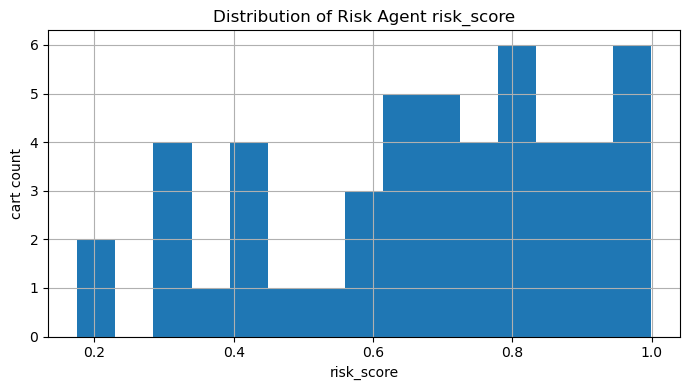

Saved plot: C:\Users\monster\Desktop\returnshield-ai\outputs\06_returnshield_agent_demo\plots\risk_score_distribution.png


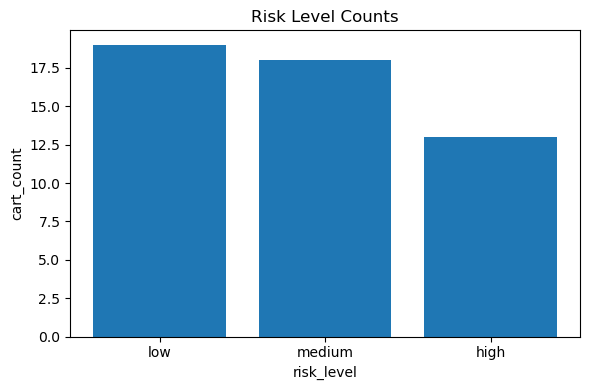

Saved plot: C:\Users\monster\Desktop\returnshield-ai\outputs\06_returnshield_agent_demo\plots\risk_level_counts.png


,risk_level,cart_count
0,low,19
1,medium,18
2,high,13


In [14]:
# Quick output views

plt.figure(figsize=(7, 4))
agent_outputs["risk_score"].hist(bins=15)
plt.title("Distribution of Risk Agent risk_score")
plt.xlabel("risk_score")
plt.ylabel("cart count")
plt.tight_layout()
risk_plot_path = PLOTS_DIR / "risk_score_distribution.png"
plt.savefig(risk_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved plot:", risk_plot_path)

risk_level_counts = agent_outputs["risk_level"].value_counts().rename_axis("risk_level").reset_index(name="cart_count")

plt.figure(figsize=(6, 4))
plt.bar(risk_level_counts["risk_level"], risk_level_counts["cart_count"])
plt.title("Risk Level Counts")
plt.xlabel("risk_level")
plt.ylabel("cart_count")
plt.tight_layout()
level_plot_path = PLOTS_DIR / "risk_level_counts.png"
plt.savefig(level_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved plot:", level_plot_path)

risk_level_counts


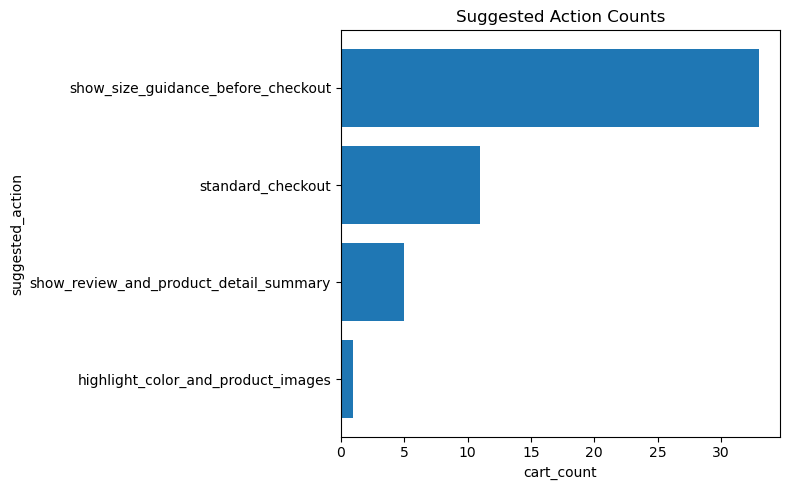

Saved plot: C:\Users\monster\Desktop\returnshield-ai\outputs\06_returnshield_agent_demo\plots\suggested_action_counts.png


,suggested_action,cart_count
0,show_size_guidance_before_checkout,33
1,standard_checkout,11
2,show_review_and_product_detail_summary,5
3,highlight_color_and_product_images,1


In [15]:
action_counts = (
    agent_outputs["suggested_action"]
    .value_counts()
    .rename_axis("suggested_action")
    .reset_index(name="cart_count")
)

plt.figure(figsize=(8, 5))
plt.barh(action_counts["suggested_action"].iloc[::-1], action_counts["cart_count"].iloc[::-1])
plt.title("Suggested Action Counts")
plt.xlabel("cart_count")
plt.ylabel("suggested_action")
plt.tight_layout()
action_plot_path = PLOTS_DIR / "suggested_action_counts.png"
plt.savefig(action_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved plot:", action_plot_path)

action_counts


## Output use

`returnshield_agent_cart_scores.csv` is the demo output for the dashboard and backend agent layer.

Important columns:

- `risk_score`
- `risk_level`
- `label_backed_risk_score`
- `contextual_evidence_score`
- `top_reasons`
- `reason_details`
- `suggested_action`
- `dashboard_message`
- layer scores used by the Risk Agent
